Download data

In [1]:
!wget https://raw.githubusercontent.com/codebasics/deep-learning-keras-tf-tutorial/refs/heads/master/7_nn_from_scratch/insurance_data.csv

--2026-04-20 04:08:39--  https://raw.githubusercontent.com/codebasics/deep-learning-keras-tf-tutorial/refs/heads/master/7_nn_from_scratch/insurance_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231 [text/plain]
Saving to: ‘insurance_data.csv’

insurance_data.csv  100%[===================>]     231  --.-KB/s    in 0s      

2026-04-20 04:08:40 (4.68 MB/s) - ‘insurance_data.csv’ saved [231/231]



Import Library

In [2]:
import numpy as np
import pandas as pd

In [ ]:
## Load Dataset

In [3]:
df=pd.read_csv('insurance_data.csv')
df.head()

,age,affordibility,bought_insurance
0,22,1,0
1,25,0,0
2,47,1,1
3,52,0,0
4,46,1,1


Data Processing

In [4]:
df["AGE"]=df["age"]/100

In [5]:
df.shape[0]

28

Sigmoid activation function

$\sigma(x) = \frac{1}{1 + e^{-x}}$

Log Loss Function

$L = - \frac{1}{n} \sum_{i=1}^{n}\left[ y_i \log(p_i) + (1 - y_i)\log(1 - p_i) \right]$

Standard Deviation

$SDT = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$

--------------------------------------------------------------------------------------------

Neural Network from Scratch

In [10]:
class NeuralNetwork:

  def __init__(self):
    self.coef=None
    self.intercept=None

  def get_weight(self):
    return self.coef,self.intercept

  def sigmoid(self,x):
    return 1 / (1 + np.exp(-x))

  def standardize(self,x):
    return (x - np.mean(x, axis=0)) / np.std(x, axis=0)

  def predict(self,x):
    weighted=np.dot(x,self.coef)+self.intercept
    return self.sigmoid(weighted)

  def predictions(self,x):
    x=self.standardize(x)
    sigmoid_output=self.predict(x)
    output=(sigmoid_output>=0.5).astype(int)
    return output

  def Log_loss(self,y_test,y_predicted):
    epsilon=1e-15
    y_predicted_new = np.clip(y_predicted, epsilon, 1 - epsilon)
    return -np.mean(y_test*np.log(y_predicted_new)+(1-y_test)*np.log(1-y_predicted_new))

  def fit(self,X,Y,epochs=1000,learning_rate=0.5):
    X_vals=X.values
    Y_vals=Y.values

    X_vals=self.standardize(X_vals)

    self.intercept=0
    self.coef=np.zeros(X_vals.shape[1])

    n=X_vals.shape[0]
    losses = []
    accuracies = []
    epoch_list = []

    for i in range(epochs+1):
        y_predicted = self.predict(X_vals)
        loss = self.Log_loss(Y_vals, y_predicted)

        error=y_predicted-Y_vals

        # Gradient descent update
        self.coef -= (learning_rate/n) * np.dot(X_vals.T, error)
        self.intercept -= (learning_rate/n) * np.sum(error)

        accuracy = np.mean(self.predictions(X_vals) == Y_vals)

        losses.append(loss)
        accuracies.append(accuracy)
        epoch_list.append(i)
        if i%10==0:
          print (f'Epoch:{i}, loss:{loss},  accuracy :{accuracy}')

    return losses,epoch_list,accuracies

Compiling the neural network

In [8]:
nn= NeuralNetwork()
losses,epoch,accuracies=nn.fit(df[["AGE", "affordibility"]],df['bought_insurance'],epochs=200,learning_rate=0.5)

Epoch:0, loss:0.6931471805599451,  accrusiey :0.6785714285714286
Epoch:10, loss:0.5464004747212312,  accrusiey :0.6785714285714286
Epoch:20, loss:0.5000016054974362,  accrusiey :0.8571428571428571
Epoch:30, loss:0.4690427217608133,  accrusiey :0.8928571428571429
Epoch:40, loss:0.44612125934678126,  accrusiey :0.8928571428571429
Epoch:50, loss:0.4286267370002676,  accrusiey :0.8928571428571429
Epoch:60, loss:0.4150685224381442,  accrusiey :0.8928571428571429
Epoch:70, loss:0.4044382753908025,  accrusiey :0.8928571428571429
Epoch:80, loss:0.3960168471632266,  accrusiey :0.9285714285714286
Epoch:90, loss:0.3892810800852153,  accrusiey :0.9285714285714286
Epoch:100, loss:0.38384575799111287,  accrusiey :0.9285714285714286
Epoch:110, loss:0.37942415483667136,  accrusiey :0.9285714285714286
Epoch:120, loss:0.3758005567719072,  accrusiey :0.9285714285714286
Epoch:130, loss:0.37281094699322465,  accrusiey :0.9285714285714286
Epoch:140, loss:0.37032932790398704,  accrusiey :0.8928571428571429
E

Visualization of the loss and *Accuracy*

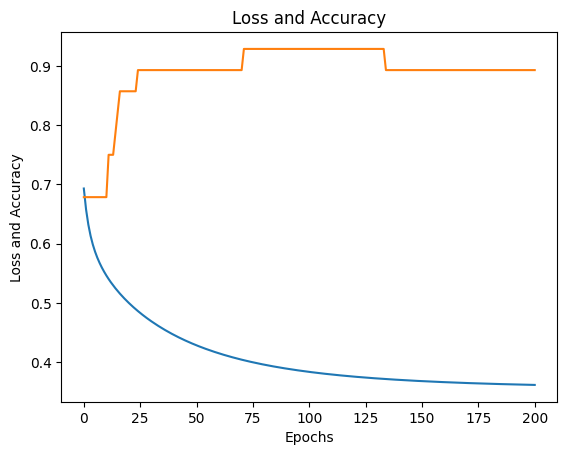

In [9]:
import matplotlib.pyplot as plt
plt.plot(epoch,losses,label="Loss")
plt.plot(epoch,accuracies,label="accuracy")
plt.title('Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss and Accuracy')
plt.show()